# Machine Learning in Computational Biology #
## Assignment 2: Heart Disease Classification using Repeated Nested Cross Validation##
### Notebook 2: Model Selection ###

### Notebook Overview ###

The second Notebook implements a repeated neste cross-validation approach, to perform model selerction, feature selection and hyperparameter tuning, and correctly determine the final model instance (tuned classifier) for heart disease classification.

### 0. Imports: ###

In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd

import sys
sys.path.append('../src')

from rncv import repeated_nested_cv
from preprocessing import build_preprocessor
from functions import display_results, plot_metric_boxplots
from functions import display_best_params

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from functions import compare_full_vs_fs
from functions import tune_final_model

import pickle
from sklearn.pipeline import Pipeline

/home/ioulios/dsit/structural/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. Data Loading ###

In [4]:
#Load the dataset
df = pd.read_csv("../data/heart.csv")

#Seperate the features and the target
X = df.drop(columns="num")
y = df["num"]

#Quick check
print(f"Quick dataset sanity check-Dataset shape:{df.shape}")
print(f"Class imbalance:\n{y.value_counts()}")


Quick dataset sanity check-Dataset shape:(242, 14)
Class imbalance:
num
0    131
1    111
Name: count, dtype: int64


### 2. Set classifiers for rncv model selection ###

In [5]:
classifiers = [
    ('LR',       LogisticRegression(penalty='elasticnet', solver='saga', 
                                     l1_ratio=0.5, max_iter=1000, random_state=42)),
    ('GNB',      GaussianNB()),
    ('LDA',      LinearDiscriminantAnalysis(solver='lsqr')),
    ('RF',       RandomForestClassifier(random_state=42)),
    ('LightGBM', LGBMClassifier(random_state=42, verbose=-1)),
    ('XGBoost',  XGBClassifier(random_state=42, verbosity=0)),
    ('CatBoost', CatBoostClassifier(random_state=42, verbose=0))
]

### 3. Hyperparameter grid definition for Optuna Tuning: ###

In [6]:
param_grids = {
    'LR': lambda trial: {
        'C': trial.suggest_float('C', 0.001, 10, log=True),
        'l1_ratio': trial.suggest_float('l1_ratio', 0.0, 1.0)
    },
    'GNB': lambda trial: {
        'var_smoothing': trial.suggest_float('var_smoothing', 1e-10, 1e-7, log=True)
    },
    'LDA': lambda trial: {
        'shrinkage': trial.suggest_float('shrinkage', 0.0, 1.0),
        'solver': 'lsqr'
    },
    'RF': lambda trial: {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    },
    'LightGBM': lambda trial: {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True)
    },
    'XGBoost': lambda trial: {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True)
    },
    'CatBoost': lambda trial: {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'depth': trial.suggest_int('depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-4, 10.0, log=True)
    }
}

### 4. Baseline Run (Model Selection without hyperparameter tuning)

Running Baseline Run (No hyperparameter tuning or feature selection)
Running baseline (no tuning)...
Done.

Baseline Results


,MCC,AUC,BA,F1,Recall,Specificity,Precision,PRAUC
Classifier,,,,,,,,
LR,0.631 (0.607–0.670),0.891 (0.878–0.908),0.811 (0.796–0.833),0.786 (0.777–0.817),0.773 (0.727–0.818),0.885 (0.846–0.885),0.838 (0.810–0.854),0.895 (0.867–0.911)
GNB,0.654 (0.623–0.692),0.893 (0.878–0.910),0.823 (0.801–0.844),0.809 (0.774–0.832),0.818 (0.739–0.818),0.846 (0.846–0.885),0.833 (0.805–0.857),0.886 (0.860–0.902)
LDA,0.664 (0.624–0.693),0.895 (0.881–0.911),0.823 (0.808–0.842),0.804 (0.785–0.828),0.773 (0.739–0.818),0.885 (0.852–0.889),0.846 (0.818–0.863),0.895 (0.873–0.915)
RF,0.586 (0.548–0.629),0.872 (0.859–0.894),0.789 (0.775–0.804),0.764 (0.750–0.782),0.727 (0.682–0.778),0.846 (0.808–0.885),0.804 (0.767–0.833),0.874 (0.855–0.895)
LightGBM,0.553 (0.538–0.590),0.856 (0.837–0.868),0.775 (0.765–0.791),0.750 (0.739–0.773),0.727 (0.696–0.773),0.811 (0.793–0.849),0.786 (0.750–0.800),0.860 (0.834–0.871)
XGBoost,0.565 (0.523–0.593),0.859 (0.837–0.874),0.777 (0.759–0.796),0.758 (0.747–0.783),0.773 (0.756–0.800),0.808 (0.769–0.846),0.773 (0.739–0.792),0.860 (0.847–0.871)
CatBoost,0.581 (0.548–0.626),0.878 (0.865–0.894),0.781 (0.774–0.809),0.764 (0.750–0.786),0.773 (0.727–0.818),0.846 (0.808–0.868),0.800 (0.762–0.821),0.879 (0.865–0.905)


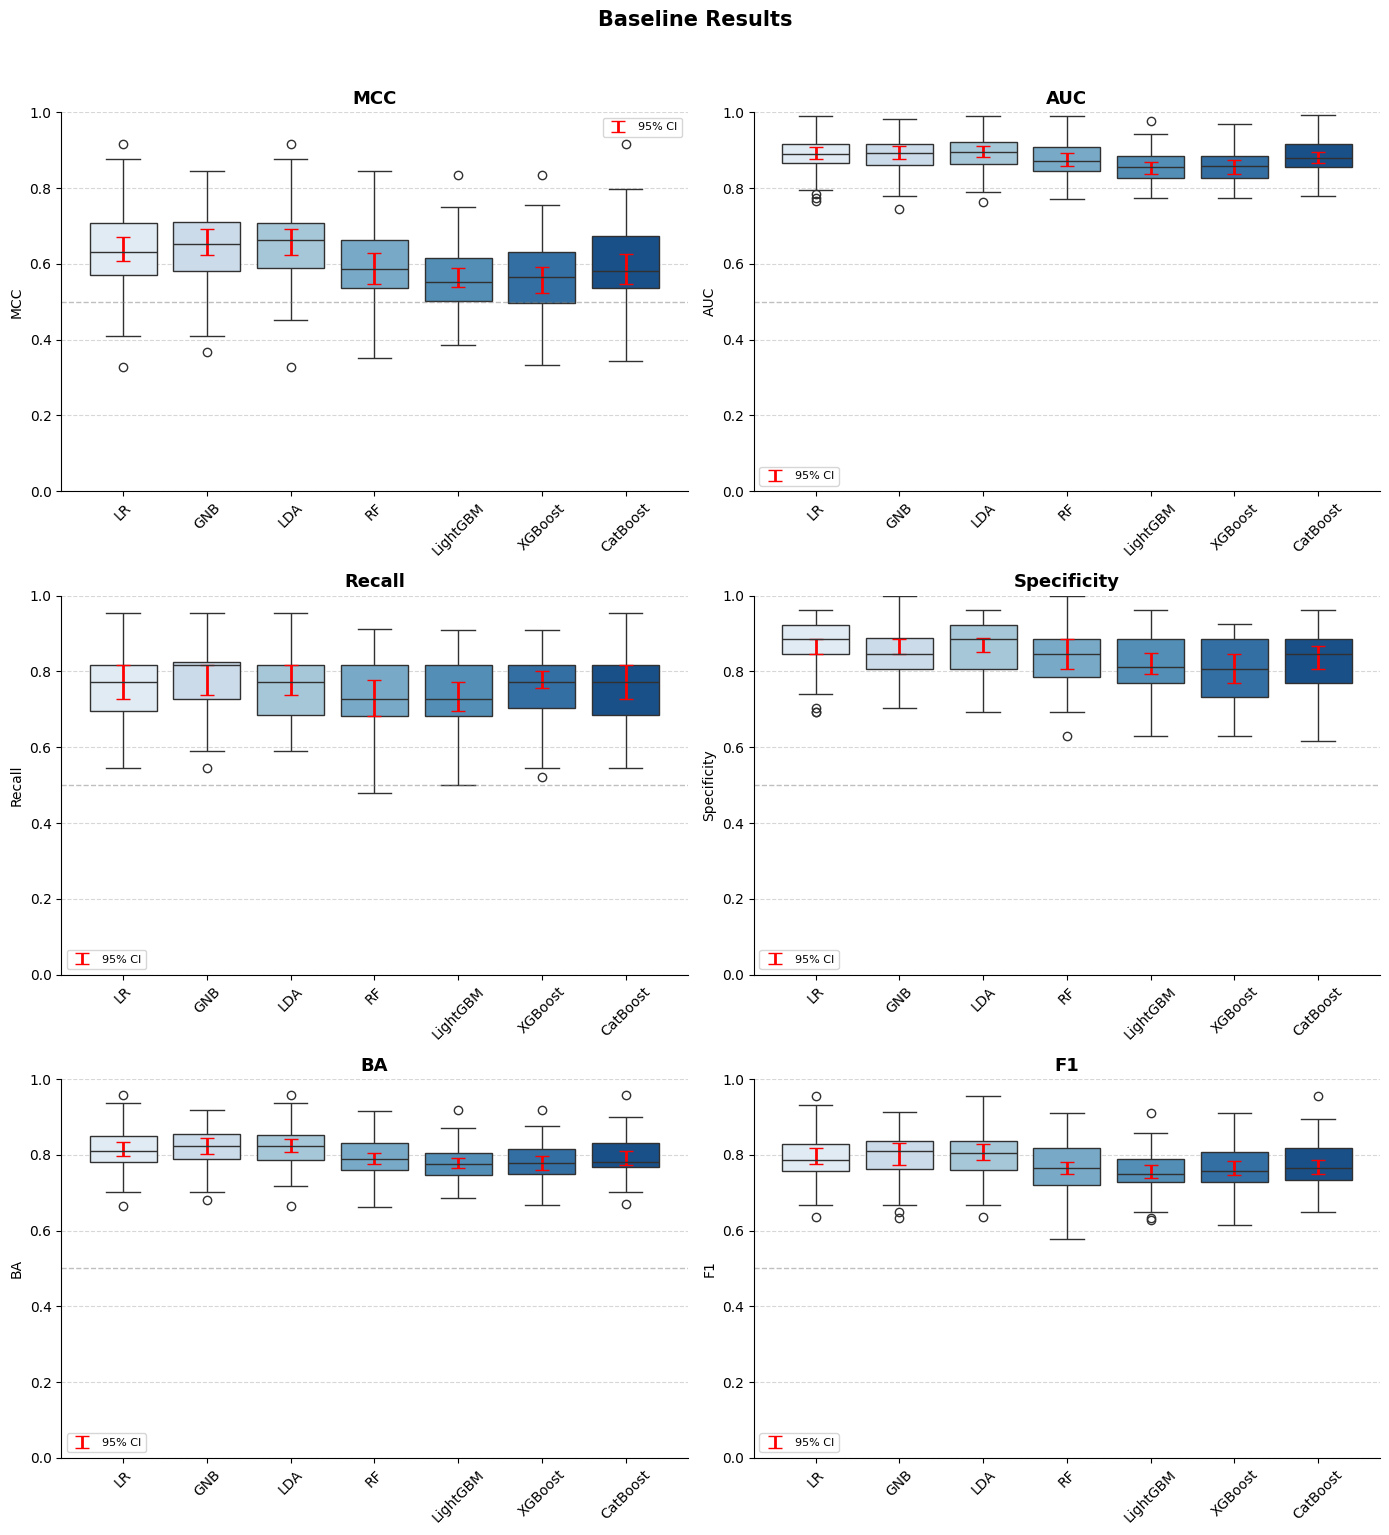

In [8]:
print("Running Baseline Run (No hyperparameter tuning or feature selection)")

ncv_baseline = repeated_nested_cv(
    classifiers=classifiers,
    parameter_grids=param_grids,
    R=10, N=5, K=3,
    tune=False,
    feature_select=False
)

ncv_baseline.fit(X, y)
baseline_results = ncv_baseline.get_results()
print("Done.")

display(display_results(baseline_results, "Baseline Results"))

plot_metric_boxplots(
    ncv_baseline,
    metrics_to_plot=['MCC', 'AUC', 'Recall', 'Specificity', 'BA', 'F1'],
    title='Baseline Results'
)

### 5. Full RNCV with Optuna Hyperparameter Tuning, with all Features: ###

[I 2026-05-11 16:46:41,641] A new study created in memory with name: no-name-052c7606-6360-487e-a1d3-b8a0697970fa
[I 2026-05-11 16:46:41,652] Trial 0 finished with value: 0.7720963327859881 and parameters: {'C': 0.03148911647956861, 'l1_ratio': 0.9507143064099162}. Best is trial 0 with value: 0.7720963327859881.
[I 2026-05-11 16:46:41,669] Trial 1 finished with value: 0.8751833607006022 and parameters: {'C': 0.8471801418819978, 'l1_ratio': 0.5986584841970366}. Best is trial 1 with value: 0.8751833607006022.
[I 2026-05-11 16:46:41,677] Trial 2 finished with value: 0.5 and parameters: {'C': 0.004207988669606638, 'l1_ratio': 0.15599452033620265}. Best is trial 1 with value: 0.8751833607006022.
[I 2026-05-11 16:46:41,684] Trial 3 finished with value: 0.5 and parameters: {'C': 0.0017073967431528124, 'l1_ratio': 0.8661761457749352}. Best is trial 1 with value: 0.8751833607006022.
[I 2026-05-11 16:46:41,699] Trial 4 finished with value: 0.8716694033935414 and parameters: {'C': 0.2537815508265

Running full rnCV (with tuning)...


[I 2026-05-11 16:46:41,834] Trial 13 finished with value: 0.8726327312534209 and parameters: {'C': 0.5095419115634501, 'l1_ratio': 0.6912602900022476}. Best is trial 6 with value: 0.8754898741105638.
[I 2026-05-11 16:46:41,856] Trial 14 finished with value: 0.8745046524356869 and parameters: {'C': 2.1819416368990985, 'l1_ratio': 0.3796042434202234}. Best is trial 6 with value: 0.8754898741105638.
[I 2026-05-11 16:46:41,880] Trial 15 finished with value: 0.8725670498084291 and parameters: {'C': 9.341529234900845, 'l1_ratio': 0.6971558983400944}. Best is trial 6 with value: 0.8754898741105638.
[I 2026-05-11 16:46:41,894] Trial 16 finished with value: 0.8693596059113301 and parameters: {'C': 0.1647668576761541, 'l1_ratio': 0.4343562717564112}. Best is trial 6 with value: 0.8754898741105638.
[I 2026-05-11 16:46:41,915] Trial 17 finished with value: 0.8748221127531473 and parameters: {'C': 1.6137610321187157, 'l1_ratio': 0.6081026755852568}. Best is trial 6 with value: 0.8754898741105638.
[

Done

Tuned Results


,MCC,AUC,BA,F1,Recall,Specificity,Precision,PRAUC
Classifier,,,,,,,,
LR,0.633 (0.603–0.709),0.894 (0.879–0.907),0.811 (0.794–0.849),0.791 (0.776–0.829),0.773 (0.727–0.800),0.885 (0.852–0.923),0.842 (0.809–0.882),0.892 (0.879–0.912)
GNB,0.654 (0.623–0.692),0.893 (0.878–0.910),0.823 (0.801–0.844),0.809 (0.774–0.832),0.818 (0.739–0.818),0.846 (0.846–0.885),0.833 (0.805–0.857),0.886 (0.860–0.902)
LDA,0.669 (0.642–0.679),0.892 (0.883–0.908),0.827 (0.813–0.837),0.805 (0.790–0.828),0.773 (0.733–0.818),0.885 (0.852–0.923),0.850 (0.815–0.889),0.896 (0.882–0.914)
RF,0.623 (0.580–0.679),0.892 (0.872–0.908),0.804 (0.780–0.826),0.780 (0.762–0.805),0.739 (0.727–0.773),0.885 (0.846–0.889),0.833 (0.800–0.864),0.890 (0.873–0.905)
LightGBM,0.582 (0.545–0.622),0.868 (0.850–0.891),0.787 (0.772–0.809),0.762 (0.756–0.791),0.773 (0.733–0.773),0.846 (0.808–0.849),0.789 (0.761–0.810),0.876 (0.857–0.897)
XGBoost,0.582 (0.547–0.631),0.866 (0.855–0.888),0.787 (0.771–0.813),0.768 (0.750–0.789),0.773 (0.727–0.773),0.846 (0.808–0.885),0.796 (0.773–0.833),0.868 (0.853–0.891)
CatBoost,0.623 (0.556–0.656),0.889 (0.874–0.906),0.801 (0.774–0.819),0.777 (0.753–0.795),0.773 (0.727–0.773),0.849 (0.846–0.885),0.810 (0.795–0.838),0.885 (0.872–0.907)


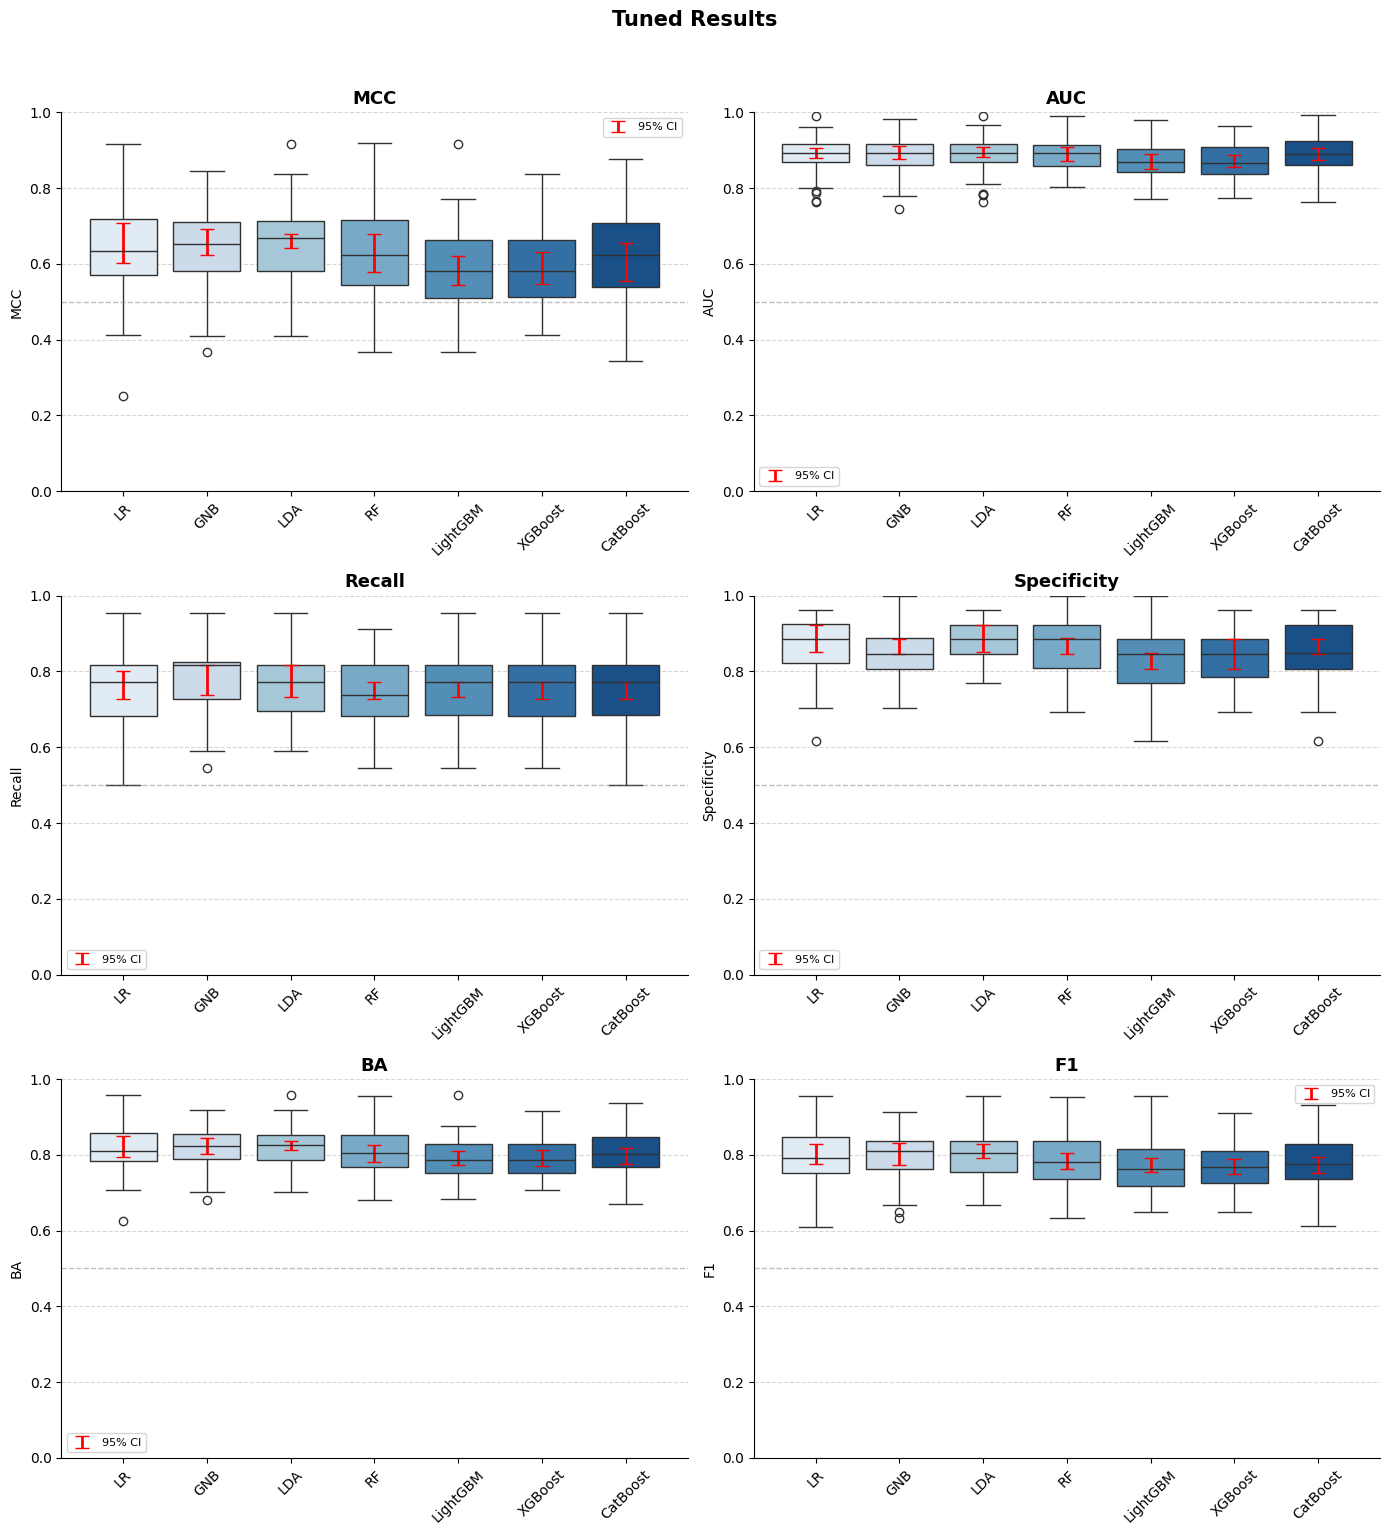

Median     Min     Max
Classifier Parameter                                
LR         C                  0.1788  0.0089  9.2287
           l1_ratio           0.0838  0.0001   0.983
GNB        var_smoothing         0.0     0.0     0.0
LDA        shrinkage          0.2398  0.0018  0.8945
RF         n_estimators        202.5     103     472
           max_depth             9.0       3      15
           min_samples_split    11.0       2      20
           min_samples_leaf      7.0       1      10
           max_features         sqrt       -       -
LightGBM   n_estimators        262.0     101     458
           max_depth             6.0       3      10
           learning_rate      0.0148    0.01  0.2987
           num_leaves           69.0      20     100
           reg_alpha          0.0558  0.0001  0.9964
           reg_lambda         0.0148  0.0001  0.9721
XGBoost    n_estimators        163.5     100     500
           max_depth             5.0       3      10
           learning_rate      0.0143  0.0101  0.1447
           subsample          0.6829  0.6006  0.9967
           colsample_bytree   0.6939  0.6005  0.9729
           reg_alpha          0.0475  0.0001  0.9952
           reg_lambda         0.0835  0.0001  0.9895
CatBoost   iterations          154.5     101     362
           depth                 5.0       3      10
           learning_rate      0.0164  0.0103  0.0324
           l2_leaf_reg        2.1423  0.0002  9.9236

In [5]:
print("Running full rnCV (with tuning)...")

ncv_tuned = repeated_nested_cv(
    classifiers=classifiers,
    parameter_grids=param_grids,
    R=10, N=5, K=3,
    tune=True,
    feature_select=False
)

ncv_tuned.fit(X, y)
tuned_results = ncv_tuned.get_results()
print("Done")

display(display_results(tuned_results, "Tuned Results"))

plot_metric_boxplots(
    ncv_tuned,
    metrics_to_plot=['MCC', 'AUC', 'Recall', 'Specificity', 'BA', 'F1'],
    title='Tuned Results'
)

display(display_best_params(ncv_tuned.get_best_params()))

### 6. Feature Selection with model - agnostic MRMR and LDA - Based k tuning ###

In [7]:
print("Running Feature selection:")
lda_classifier = [('LDA', LinearDiscriminantAnalysis(solver='lsqr'))]

ncv_fs = repeated_nested_cv(
    classifiers=lda_classifier,
    parameter_grids=param_grids,
    R=10, N=5, K=3,
    tune=True,
    feature_select=True
)

ncv_fs.fit(X, y)
fs_results = ncv_fs.get_results()
print("Done!")

Running Feature selection:


100%|██████████| 13/13 [00:03<00:00,  3.89it/s]
[I 2026-05-13 00:17:12,255] A new study created in memory with name: no-name-0dc054a8-8cf2-48b7-9507-b8d4a2f59041
[I 2026-05-13 00:17:12,263] Trial 0 finished with value: 0.8955062944718118 and parameters: {'shrinkage': 0.3745401188473625}. Best is trial 0 with value: 0.8955062944718118.
[I 2026-05-13 00:17:12,271] Trial 1 finished with value: 0.8906787082649151 and parameters: {'shrinkage': 0.9507143064099162}. Best is trial 0 with value: 0.8955062944718118.
[I 2026-05-13 00:17:12,280] Trial 2 finished with value: 0.8945648604269293 and parameters: {'shrinkage': 0.7319939418114051}. Best is trial 0 with value: 0.8955062944718118.
[I 2026-05-13 00:17:12,289] Trial 3 finished with value: 0.8945539135194308 and parameters: {'shrinkage': 0.5986584841970366}. Best is trial 0 with value: 0.8955062944718118.
[I 2026-05-13 00:17:12,300] Trial 4 finished with value: 0.8994362342638205 and parameters: {'shrinkage': 0.15601864044243652}. Best is tr

Done!


### Visualization of feature selection results ###


LDA with Feature Selection


,MCC,AUC,BA,F1,Recall,Specificity,Precision,PRAUC
Classifier,,,,,,,,
LDA,0.664 (0.622–0.674),0.883 (0.871–0.902),0.823 (0.806–0.832),0.800 (0.783–0.818),0.773 (0.733–0.818),0.849 (0.846–0.923),0.818 (0.804–0.878),0.883 (0.868–0.908)


Feature Frequencies


,feature,count,frequency
0,exang,50,1.00
1,thal,50,1.00
2,oldpeak,49,0.98
3,ca,43,0.86
4,fbs,42,0.84
5,trestbps,36,0.72
6,thalach,27,0.54
7,chol,23,0.46
8,restecg,20,0.40
9,age,6,0.12



Stable features (selected in >70% of folds): 6


,feature,count,frequency
0,exang,50,1.00
1,thal,50,1.00
2,oldpeak,49,0.98
3,ca,43,0.86
4,fbs,42,0.84
5,trestbps,36,0.72


LDA with full feature set vs only stable features


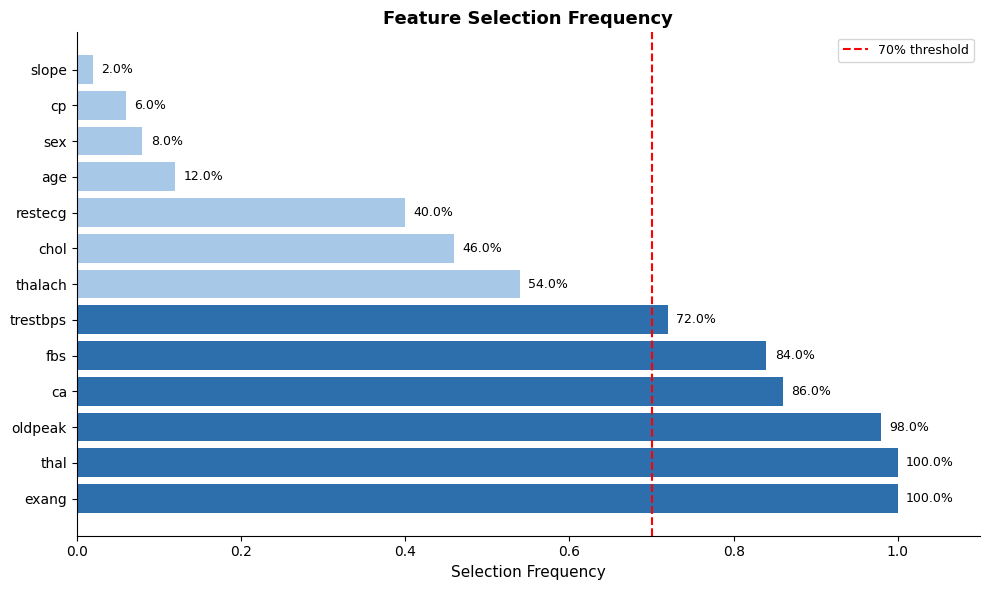

In [ ]:
#Display metrics from run with Feature selection
fs_results = ncv_fs.get_results()
display(display_results(fs_results, "LDA with Feature Selection"))

#Display frequency across CV of each feature
print("Feature Frequencies")
freq_df = ncv_fs.get_feature_frequencies(X.columns.tolist())
display(freq_df)

#Show Most stable features (>70% of folds)
stable = freq_df[freq_df['frequency'] >= 0.7]
print(f"\nStable features (selected in >70% of folds): {len(stable)}")
display(stable)

#LDA with vs without feature selection
print("LDA with full feature set vs only stable features")
display(compare_full_vs_fs(tuned_results, fs_results, 'LDA'))

from functions import plot_feature_frequencies

freq_df = ncv_fs.get_feature_frequencies(X.columns.tolist())
plot_feature_frequencies(freq_df, title='Feature Selection Frequency')

### 7. Final model tuning on the whole dataset ###

In [30]:
best_params = tune_final_model(
    X, y,
    classifier=LinearDiscriminantAnalysis(solver='lsqr'),  # instance not class
    param_grid=param_grids['LDA']
)

[I 2026-05-10 17:58:22,615] A new study created in memory with name: no-name-f47dac20-4e37-4ddd-b504-405104292d0d
[I 2026-05-10 17:58:22,776] Trial 0 finished with value: 0.8969370404153013 and parameters: {'shrinkage': 0.3745401188473625}. Best is trial 0 with value: 0.8969370404153013.
[I 2026-05-10 17:58:22,929] Trial 1 finished with value: 0.8852977939934462 and parameters: {'shrinkage': 0.9507143064099162}. Best is trial 0 with value: 0.8969370404153013.
[I 2026-05-10 17:58:23,093] Trial 2 finished with value: 0.8872785829307569 and parameters: {'shrinkage': 0.7319939418114051}. Best is trial 0 with value: 0.8969370404153013.
[I 2026-05-10 17:58:23,247] Trial 3 finished with value: 0.8907407407407408 and parameters: {'shrinkage': 0.5986584841970366}. Best is trial 0 with value: 0.8969370404153013.
[I 2026-05-10 17:58:23,417] Trial 4 finished with value: 0.8986267355832573 and parameters: {'shrinkage': 0.15601864044243652}. Best is trial 4 with value: 0.8986267355832573.
[I 2026-05

Best AUC: 0.9007
Best parameters: {'shrinkage': 0.203082290936859}


### 8. Save Final model ###

In [33]:
#Build the final pipeline (preprocessing and classifier)
final_pipeline = Pipeline(steps=[
    ("preprocessor", build_preprocessor()),
    ("classifier", LinearDiscriminantAnalysis(solver="lsqr", **best_params))
])

#Train on the full dataset
final_pipeline.fit(X,y)

#save
import os
os.makedirs('../models', exist_ok=True)

with open('../models/final_model.pkl', 'wb') as f:
    pickle.dump(final_pipeline, f)

    


### 9. SHAP Analysis ###

In [37]:
import shap

# extract preprocessor and classifier from pipeline
preprocessor = final_pipeline.named_steps['preprocessor']
classifier = final_pipeline.named_steps['classifier']

# preprocess all data
X_processed = preprocessor.transform(X)

# create explainer
explainer = shap.LinearExplainer(classifier, X_processed)
shap_values = explainer.shap_values(X_processed)

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (242, 13)


### SHAP global analysis plots ###

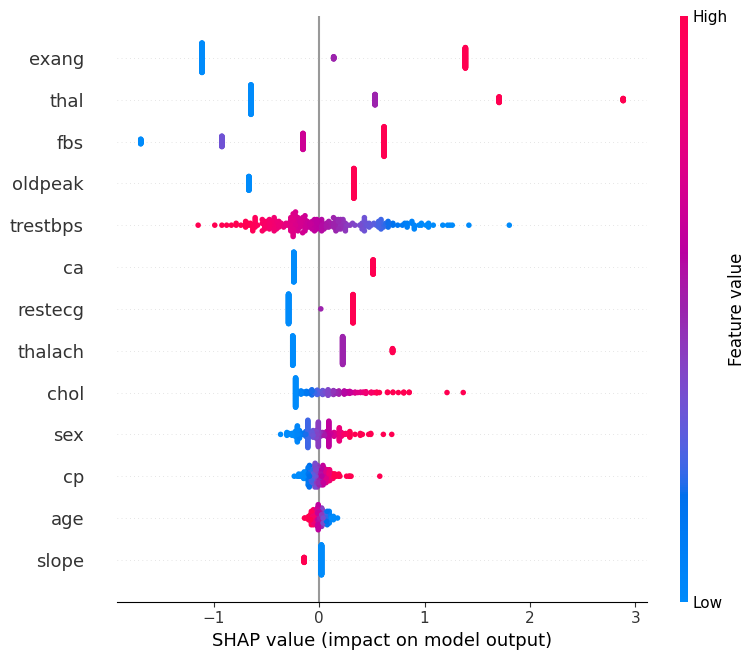

In [38]:
shap.summary_plot(
    shap_values,
    X_processed,
    feature_names=X.columns.tolist(),
    show=True
)

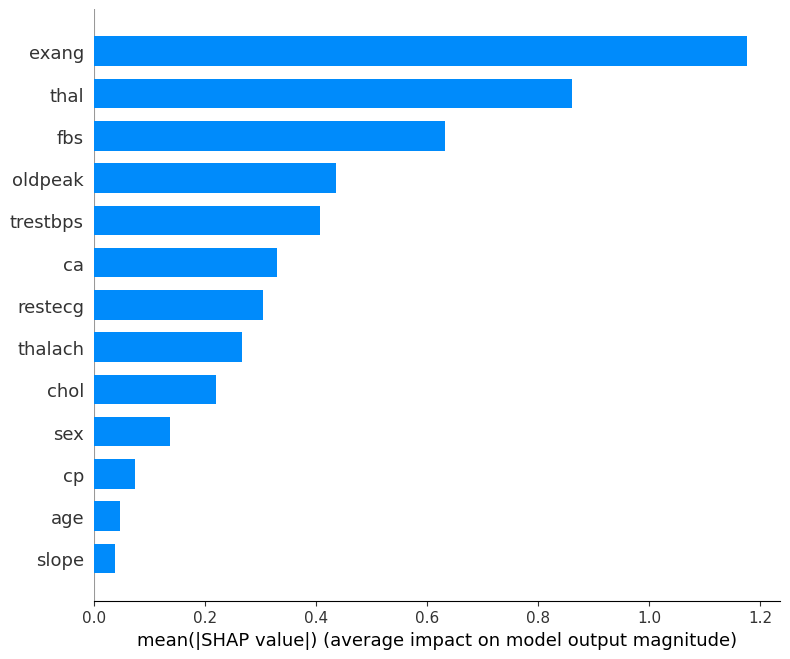

In [39]:
shap.summary_plot(
    shap_values,
    X_processed,
    feature_names=X.columns.tolist(),
    plot_type='bar',
    show=True
)